In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
ga_results = pd.read_csv("../../results/ga_result.csv")
gp_results = pd.read_csv("../../results/gp_result.csv")
gs_results = pd.read_csv("../../results/gridsearch_result.csv")

gdf = gpd.read_file("../../data/eolico_10_m/Zona_F_Eolico_10m.shp")
gdf = gdf.to_crs(epsg=9377)
polygon_1 = gdf.geometry.iloc[33601] # e_10m_33602
polygon_2 = gdf.geometry.iloc[36598] # e_10m_36599
polygon_3 = gdf.geometry.iloc[33929] # e_10m_33930
polygon_4 = gdf.geometry.iloc[36643] # e_10m_36644

e_10m_34268##BAD
e_10m_36662##BUENO


NameError: name 'e_10m_34268' is not defined

In [104]:
geometry_sb = gdf.geometry.iloc[33601]
geometry_sg = gdf.geometry.iloc[36598]
geometry_bb = gdf.geometry.iloc[33929]
geometry_bg = gdf.geometry.iloc[36643]
geometry_mb = gdf.geometry.iloc[34267]
geometry_mg = gdf.geometry.iloc[36661]

print("geometry_sb", f"{geometry_sb.area:.2f}")
print("geometry_sg", f"{geometry_sg.area:.2f}")
print("geometry_bb", f"{geometry_bb.area:.2f}")
print("geometry_bg", f"{geometry_bg.area:.2f}")
print("geometry_mb", f"{geometry_mb.area:.2f}")
print("geometry_mg", f"{geometry_mg.area:.2f}")

geometry_sb 80156.08
geometry_sg 49153.33
geometry_bb 5995020.90
geometry_bg 9134750.75
geometry_mb 387579.55
geometry_mg 443616.44


In [100]:
print(polygon_1.area)
print(polygon_2.area)
print(polygon_3.area)
print(polygon_4.area)

80156.08070277954
49153.32702909547
5995020.900522847
9134750.753683023


In [21]:
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D

def plot_raster_pixels_raw(ax, xs, ys, pixel_size, original_polygon=None):
    """
    Plots explicit list of X and Y pixel coordinates as true-to-size square grid cells.

    Parameters:
    - xs: List or array of X coordinates (pixel centers)
    - ys: List or array of Y coordinates (pixel centers)
    - pixel_size: The resolution/size of each pixel in map units
    - original_polygon: Optional shapely Polygon to overlay for comparison
    """
    # 1. Initialize the plot
    # fig, ax = plt.subplots(figsize=(8, 8))

    # 2. Build a list of square patches centered on each X, Y coordinate pair
    patches = [
        Rectangle(
            xy=(x - pixel_size / 2, y - pixel_size / 2),
            width=pixel_size,
            height=pixel_size,
        )
        for x, y in zip(xs, ys)
    ]

    # 3. Bundle patches into a Collection for fast rendering
    pc = PatchCollection(
        patches, facecolor="skyblue", edgecolor="dodgerblue", alpha=0.7
    )
    ax.add_collection(pc)

    # 4. Optional: Overlay the original polygon boundary
    if original_polygon is not None:
        x_poly, y_poly = original_polygon.exterior.xy
        ax.plot(
            x_poly, y_poly, color="red", linewidth=2, label="Original Polygon"
        )

    # 5. Build a custom legend
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor="skyblue",
            markeredgecolor="dodgerblue",
            markersize=12,
            label="Rasterized Pixels",
        )
    ]
    if original_polygon is not None:
        legend_elements.append(
            Line2D(
                [0], [0], color="red", lw=2, label="Original Polygon Boundary"
            )
        )

    # 6. Format the plot bounds and aesthetics
    ax.autoscale_view()
    ax.set_aspect(
        "equal"
    )  # Critical to keep squares from turning into rectangles
    ax.set_xlabel("X Coordinate (Map Units)")
    ax.set_ylabel("Y Coordinate (Map Units)")
    ax.set_title(f"Rasterized Grid Mapping (Pixel Size = {pixel_size})")
    ax.legend(handles=legend_elements, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.3)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np


def plot_interactive_dataset(history, x_pos, y_pos, polygon, spacing):
    """Plots a static baseline alongside a dynamic curve controlled by a Slider.

    Parameters:
    - x_data: 1D array/list for the x-axis.
    - static_data_list: List/array of y-values that do NOT change.
    - dynamic_datasets: List of 1D arrays/lists representing different
                        graph states corresponding to slider index positions.
    """
    # 1. Create main figure and split layout for plot + slider
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.subplots_adjust(bottom=0.25)  # Leave room at the bottom for slider
    ###
    patches = [
        Rectangle(
            xy=(x - spacing / 2, y - spacing / 2),
            width=spacing,
            height=spacing,
        )
        for x, y in zip(x_pos, y_pos)
    ]

    # 3. Bundle patches into a Collection for fast rendering
    pc = PatchCollection(
        patches, facecolor="skyblue", edgecolor="dodgerblue", alpha=0.7
    )
    ax.add_collection(pc)
    ###

    if polygon is not None:
        x_poly, y_poly = polygon.exterior.xy
        ax.plot(
            x_poly, y_poly, color="red", linewidth=2, label="Original Polygon"
        )

    initial_idx = 0
    mask = np.array(history[initial_idx]).astype(bool)

    final_x = x_pos[mask]
    final_y = y_pos[mask]
    scatter = ax.scatter(final_x, final_y, marker="x")


    # 4. Style the plot area
    ax.set_title("Evolution of algo")
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right")

    # 5. Define slider position axes: [left, bottom, width, height]
    ax_slider = plt.axes([0.15, 0.1, 0.7, 0.03])

    # 6. Instantiate the integer index Slider
    index_slider = Slider(
        ax=ax_slider,
        label="Index State",
        valmin=0,
        valmax=len(history) - 1,
        valinit=initial_idx,
        valstep=1,  # Snap to discrete integer indices
    )

    # 7. Define callback function triggered by slider changes
    def update(val):
        idx = int(index_slider.val)  # Get current slider index integer

        # Update ONLY the dynamic line data
        mask = np.array(history[idx]).astype(bool)
        final_x = x_pos[mask]
        final_y = y_pos[mask]

        new_offsets = np.column_stack((final_x, final_y))

        # Update both X and Y coordinates at once
        scatter.set_offsets(new_offsets)

        # Redraw the canvas
        fig.canvas.draw_idle()

    # 8. Attach callback to slider event
    index_slider.on_changed(update)

    plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_ax(fig, ax, df, config_val, num_col, fmt=".2f", cmap="viridis"):
    """
    Plots an annotated heatmap of 'polygon' vs 'fn' for a selected 'config' category 
    onto a provided Matplotlib Figure and Axes object.
    
    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        The parent figure object (needed for adding the colorbar).
    ax : matplotlib.axes.Axes
        The specific subplot axes where the heatmap will be drawn.
    df : pandas.DataFrame
        Input DataFrame.
    config_val : str or int
        The category value in the 'config' column to filter by.
    num_col : str
        The numerical column to plot ('fitness', 'aep_wake', 'park_cf', 'park_loss').
    fmt : str, default '.2f'
        Format specifier for cell values (e.g., '.2f', '.1f', '.0f').
    cmap : str, default 'viridis'
        Matplotlib colormap scheme.
    """
    # 1. Filter DataFrame by the given config
    filtered_df = df[df['config'] == config_val]
    
    if filtered_df.empty:
        raise ValueError(f"No rows found for config = '{config_val}'")
    
    # 2. Pivot the data
    pivot_df = filtered_df.pivot(index='polygon', columns='fn', values=num_col)
    
    data_matrix = pivot_df.values
    row_labels = pivot_df.index.tolist()
    col_labels = pivot_df.columns.tolist()
    
    # 3. Draw heatmap on the passed `ax`
    im = ax.imshow(data_matrix, cmap=cmap)
    
    # Add colorbar attached to the parent `fig`
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(num_col, rotation=-90, va="bottom", fontsize=10)
    
    # Set tick labels
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)
    
    # Axis labels and title
    ax.set_xlabel('FN', fontsize=11)
    ax.set_ylabel('Polygon', fontsize=11)
    ax.set_title(f'{num_col} (Config: {config_val})', fontsize=12, pad=10)
    
    # 4. Annotate cells with adaptive text color for readability
    norm = im.norm
    cmap_obj = plt.get_cmap(cmap)
    
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            val = data_matrix[i, j]
            if not np.isnan(val):
                # Calculate relative luminance to decide white/black text
                rgba = cmap_obj(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "white" if luminance < 0.5 else "black"
                
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center", color=text_color, fontweight='bold')

In [24]:
ga_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   112 non-null    int64  
 1   polygon      112 non-null    str    
 2   fn           112 non-null    str    
 3   config       112 non-null    str    
 4   fitness      112 non-null    float64
 5   aep_wake     112 non-null    float64
 6   park_cf      112 non-null    float64
 7   park_loss    112 non-null    float64
 8   history      112 non-null    str    
 9   x_positions  112 non-null    str    
 10  y_positions  112 non-null    str    
 11  spacing      112 non-null    float64
dtypes: float64(5), int64(1), str(6)
memory usage: 10.6 KB


SPACING 21.0


/tmp/ipykernel_49393/2038910216.py:60: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  index_slider = Slider(


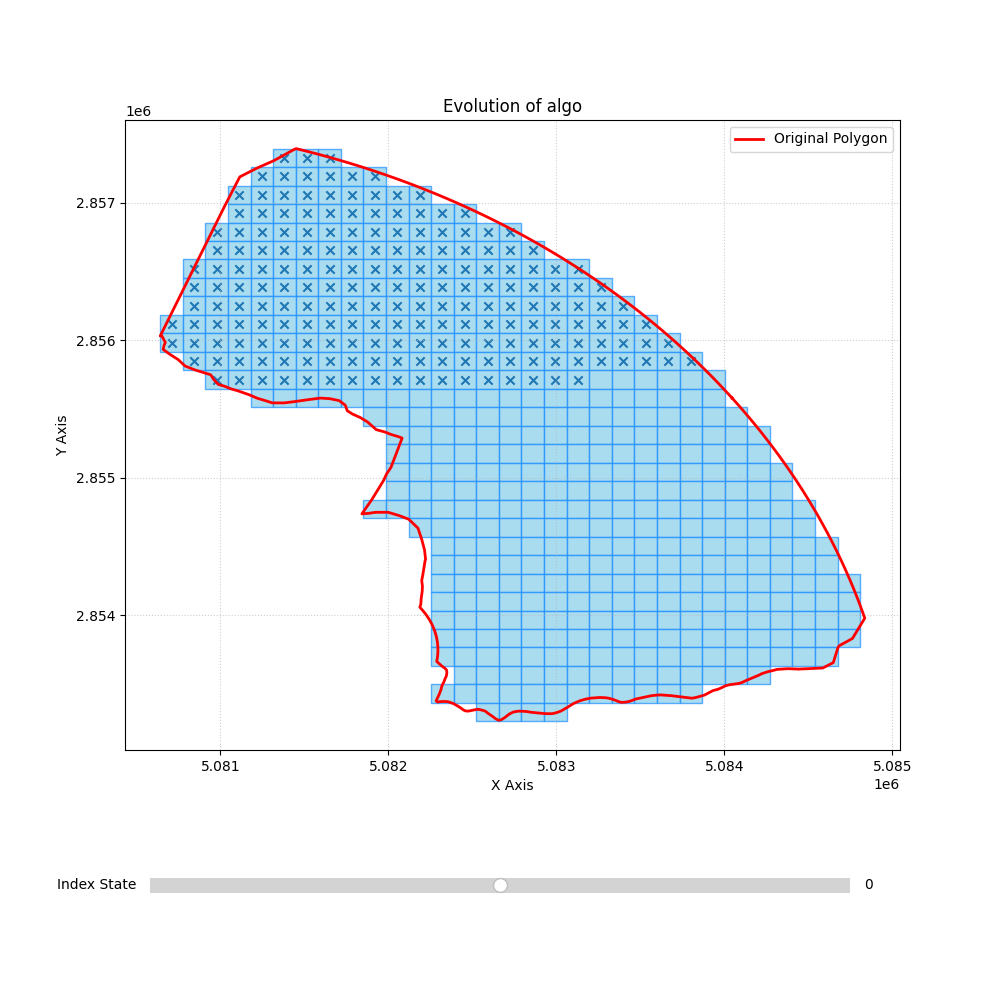

In [36]:
%matplotlib widget
import ast
def show_ga_history(geom, polygon, config, fn):

    filtered_df = ga_results[
        (ga_results["polygon"] == polygon) & (ga_results["config"] == config) & (ga_results["fn"] == fn)
    ]
    cromosome = ast.literal_eval(filtered_df["history"].values[0])
    xs = np.array(ast.literal_eval(filtered_df["x_positions"].values[0]))
    ys = np.array(ast.literal_eval(filtered_df["y_positions"].values[0]))
    spacing = filtered_df["spacing"].values[0]
    print("SPACING", spacing)
    plot_interactive_dataset(
        history=cromosome, x_pos=xs, y_pos=ys, spacing=spacing*6.4, polygon=geom
    )

show_ga_history(polygon_4,"polygon 4", "config 1", "fn 1")

In [ ]:
ga_results["config"].unique()


<StringArray>
['config 1', 'config 2', 'config 3', 'config 4']
Length: 4, dtype: str

In [ ]:
import math
def plot_all_results(df):
    configs = df["config"].unique()

    for idx, c in enumerate(configs):
        fig, axes = plt.subplots(2, 2, figsize=(20, 10))
        print(c)
        plot_heatmap_ax(fig, axes[0,0], df, c, "fitness", fmt=".1e")
        plot_heatmap_ax(fig, axes[0,1], df, c, "aep_wake", fmt=".1e")
        plot_heatmap_ax(fig, axes[1,0], df, c, "park_cf")
        plot_heatmap_ax(fig, axes[1,1], df, c, "park_loss")


# GA Results

In [49]:
ga_results

,Unnamed: 0,polygon,fn,config,fitness,aep_wake,park_cf,park_loss,history
0,0,polygon 1,fn 1,config 1,1.349588e+05,1.349588e+05,0.051489,0.193830,"[[1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,..."
1,1,polygon 1,fn 1,config 2,1.527594e+05,1.527594e+05,0.048567,0.239582,"[[1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,..."
2,2,polygon 1,fn 1,config 3,1.532113e+05,1.532113e+05,0.048711,0.237333,"[[1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,..."
3,3,polygon 1,fn 1,config 4,1.526239e+05,1.526239e+05,0.049208,0.229556,"[[1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,..."
4,4,polygon 1,fn 2,config 1,6.037828e-02,5.011488e+04,0.060378,0.054656,"[[1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,..."
...,...,...,...,...,...,...,...,...,...
107,107,polygon 4,fn 6,config 4,4.783411e+06,4.783408e+06,0.547489,0.000000,"[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
108,108,polygon 4,fn 7,config 1,4.783409e+06,4.783408e+06,0.547489,0.000000,"[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
109,109,polygon 4,fn 7,config 2,4.783409e+06,4.783408e+06,0.547489,0.000000,"[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
110,110,polygon 4,fn 7,config 3,4.783409e+06,4.783408e+06,0.547489,0.000000,"[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."


config 1
config 2
config 3
config 4


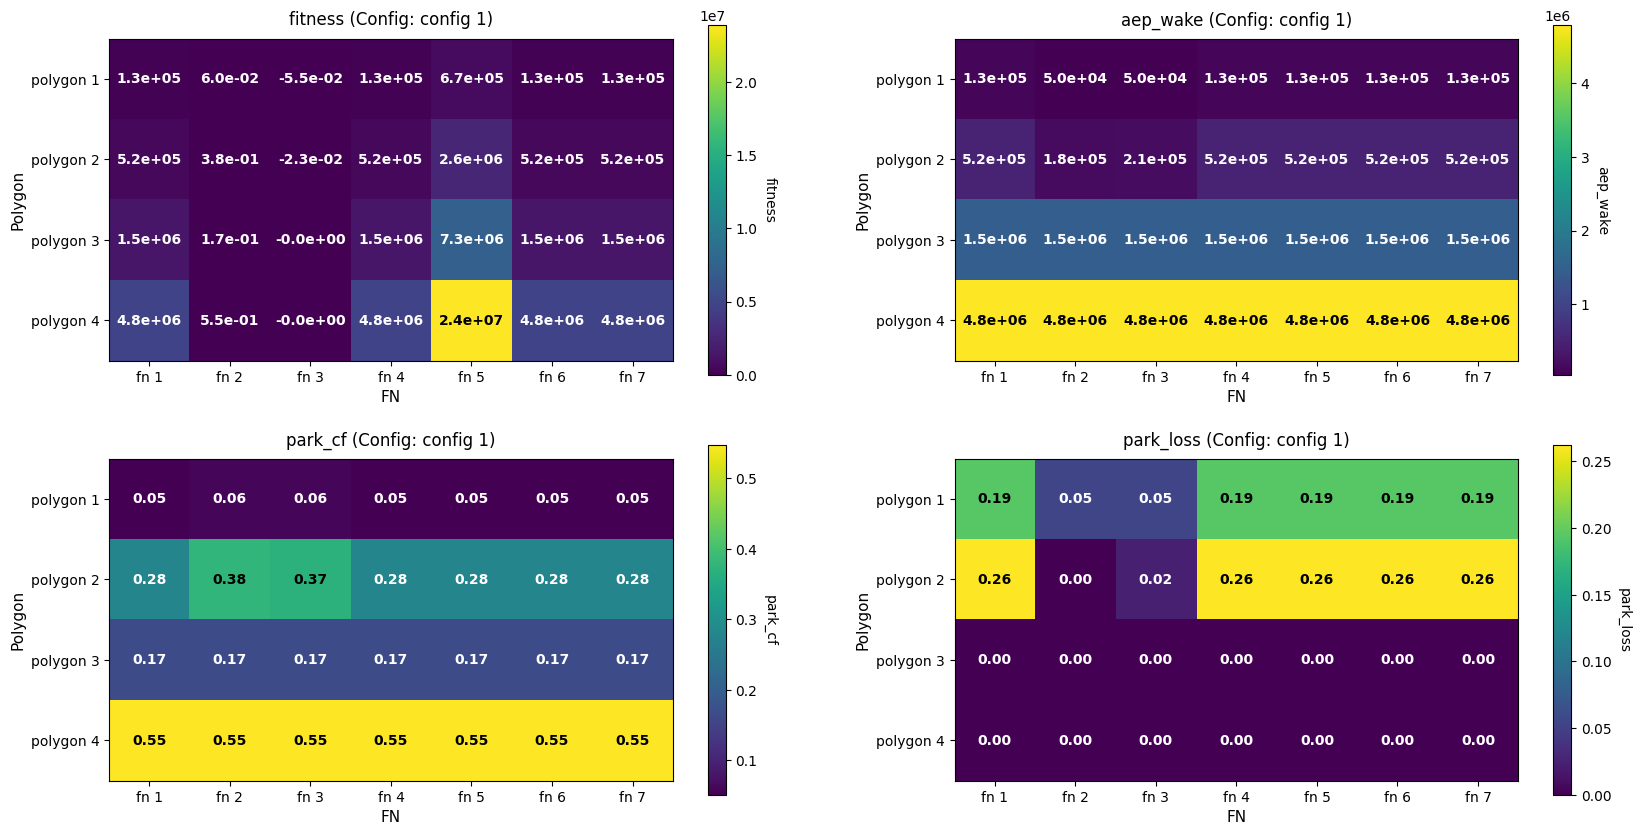

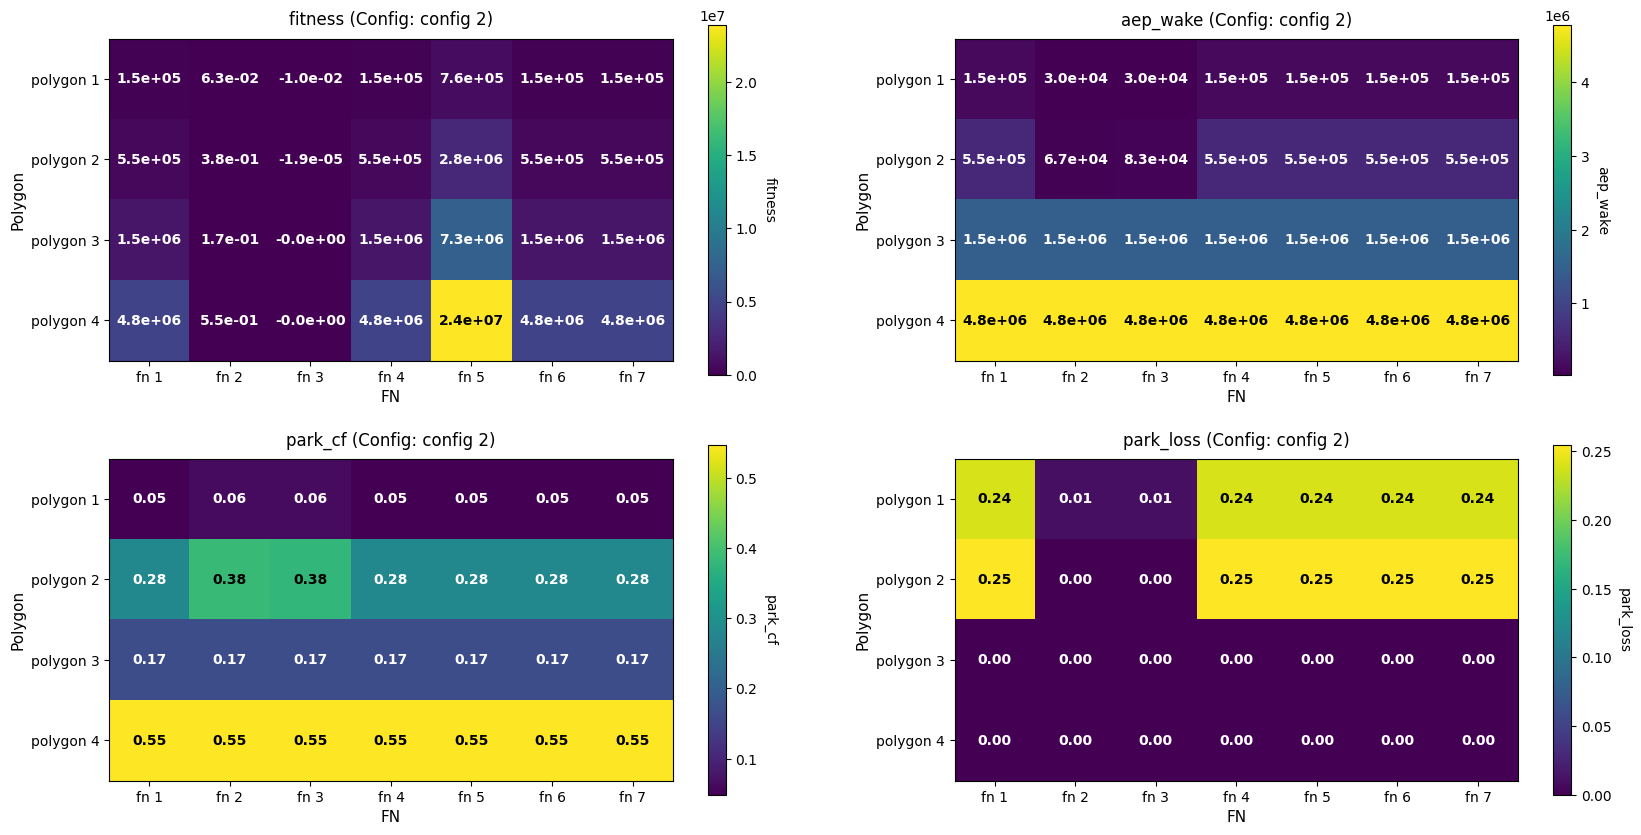

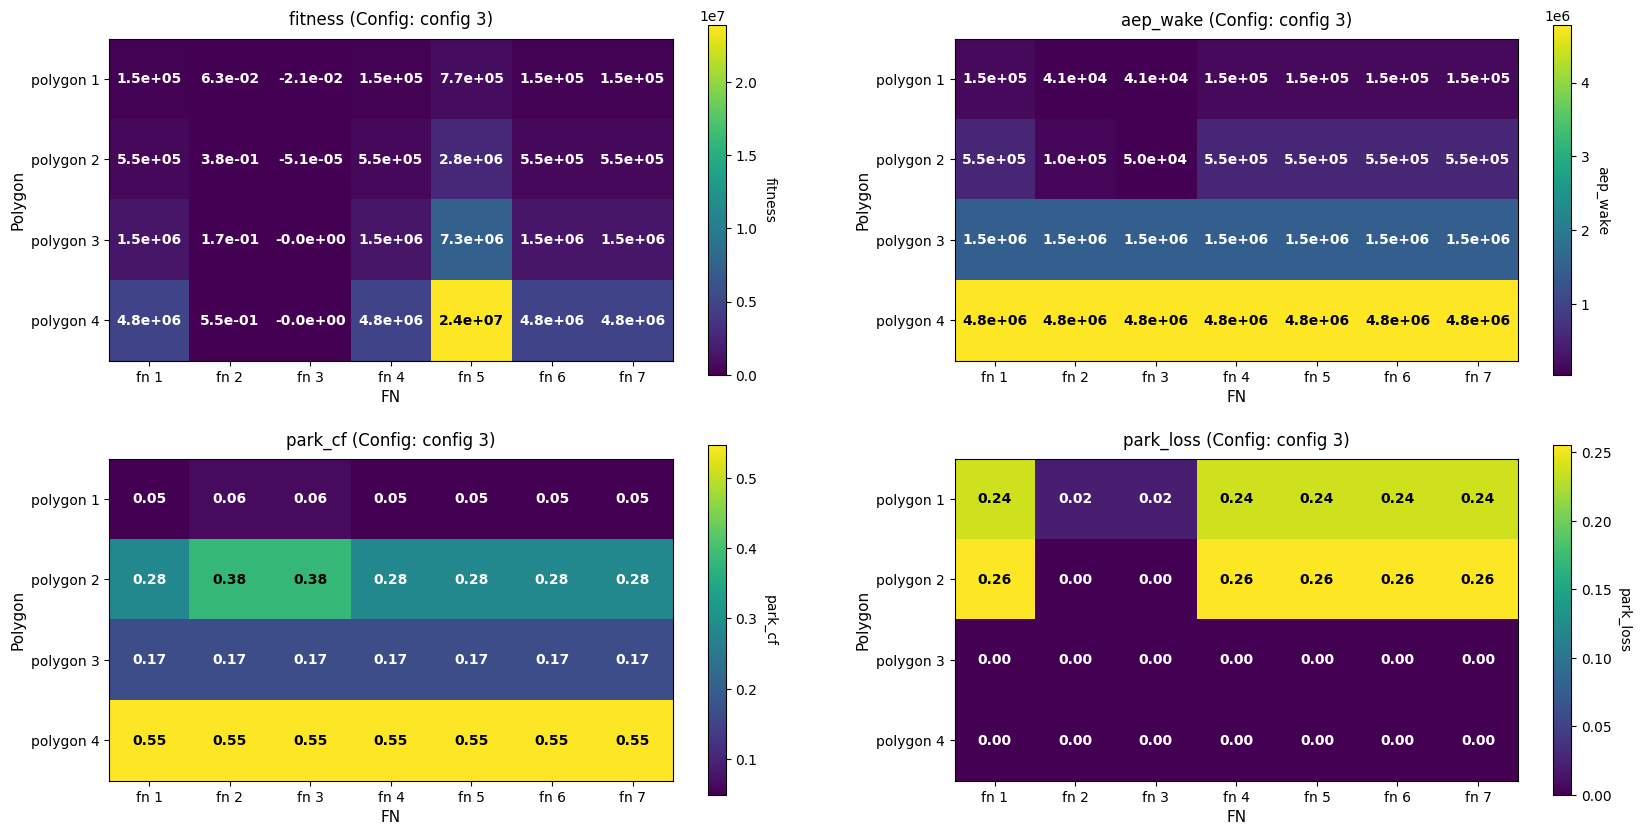

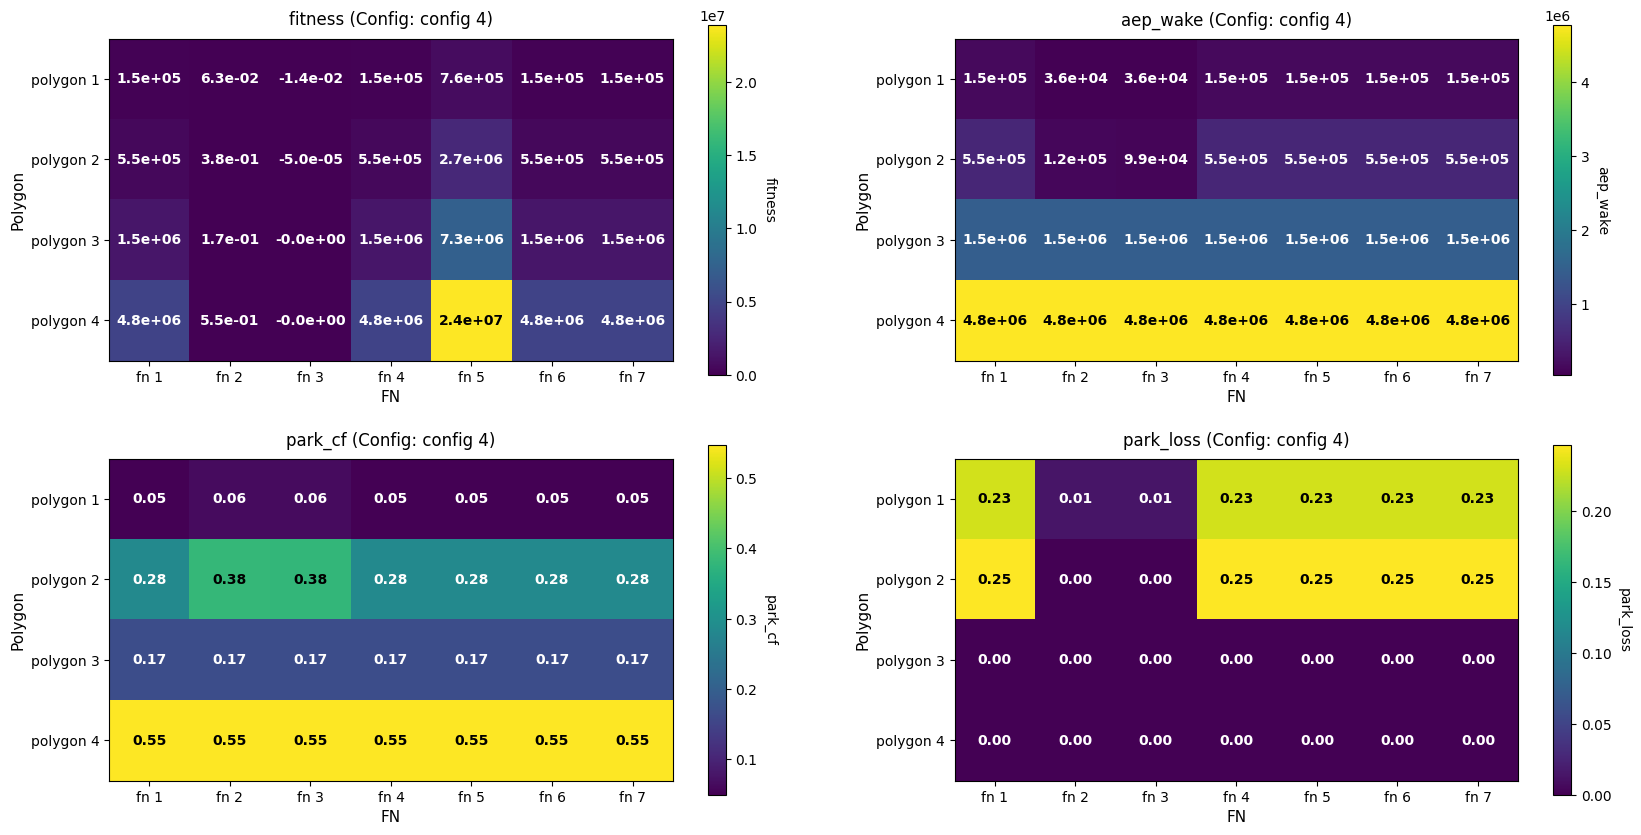

In [26]:
plot_all_results(ga_results)

In [45]:
ga_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  112 non-null    int64  
 1   polygon     112 non-null    str    
 2   fn          112 non-null    str    
 3   config      112 non-null    str    
 4   fitness     112 non-null    float64
 5   aep_wake    112 non-null    float64
 6   park_cf     112 non-null    float64
 7   park_loss   112 non-null    float64
dtypes: float64(4), int64(1), str(3)
memory usage: 7.1 KB


# GP Results

In [41]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np


def plot_interactive_dataset_gp(x_pos, y_pos, polygon):
    """Plots a static baseline alongside a dynamic curve controlled by a Slider.

    Parameters:
    - x_data: 1D array/list for the x-axis.
    - static_data_list: List/array of y-values that do NOT change.
    - dynamic_datasets: List of 1D arrays/lists representing different
                        graph states corresponding to slider index positions.
    """
    # 1. Create main figure and split layout for plot + slider
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.subplots_adjust(bottom=0.25)  # Leave room at the bottom for slider

    if polygon is not None:
        x_poly, y_poly = polygon.exterior.xy
        ax.plot(
            x_poly, y_poly, color="red", linewidth=2, label="Original Polygon"
        )

    initial_idx = 0
    scatter = ax.scatter(x_pos[initial_idx], y_pos[initial_idx], marker="x")


    # 4. Style the plot area
    ax.set_title("Evolution of algo")
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right")

    # 5. Define slider position axes: [left, bottom, width, height]
    ax_slider = plt.axes([0.15, 0.1, 0.7, 0.03])

    # 6. Instantiate the integer index Slider
    index_slider = Slider(
        ax=ax_slider,
        label="Index State",
        valmin=0,
        valmax=len(x_pos) - 1,
        valinit=initial_idx,
        valstep=1,  # Snap to discrete integer indices
    )

    # 7. Define callback function triggered by slider changes
    def update(val):
        idx = int(index_slider.val)  # Get current slider index integer
        new_offsets = np.column_stack((x_pos[idx], y_pos[idx]))

        # Update both X and Y coordinates at once
        scatter.set_offsets(new_offsets)

        # Redraw the canvas
        fig.canvas.draw_idle()

    # 8. Attach callback to slider event
    index_slider.on_changed(update)

    plt.show()

In [44]:
gp_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  112 non-null    int64  
 1   polygon     112 non-null    str    
 2   fn          112 non-null    str    
 3   config      112 non-null    str    
 4   fitness     112 non-null    float64
 5   aep_wake    112 non-null    float64
 6   park_cf     112 non-null    float64
 7   park_loss   112 non-null    float64
 8   x_history   112 non-null    str    
 9   y_history   112 non-null    str    
dtypes: float64(4), int64(1), str(5)
memory usage: 8.9 KB


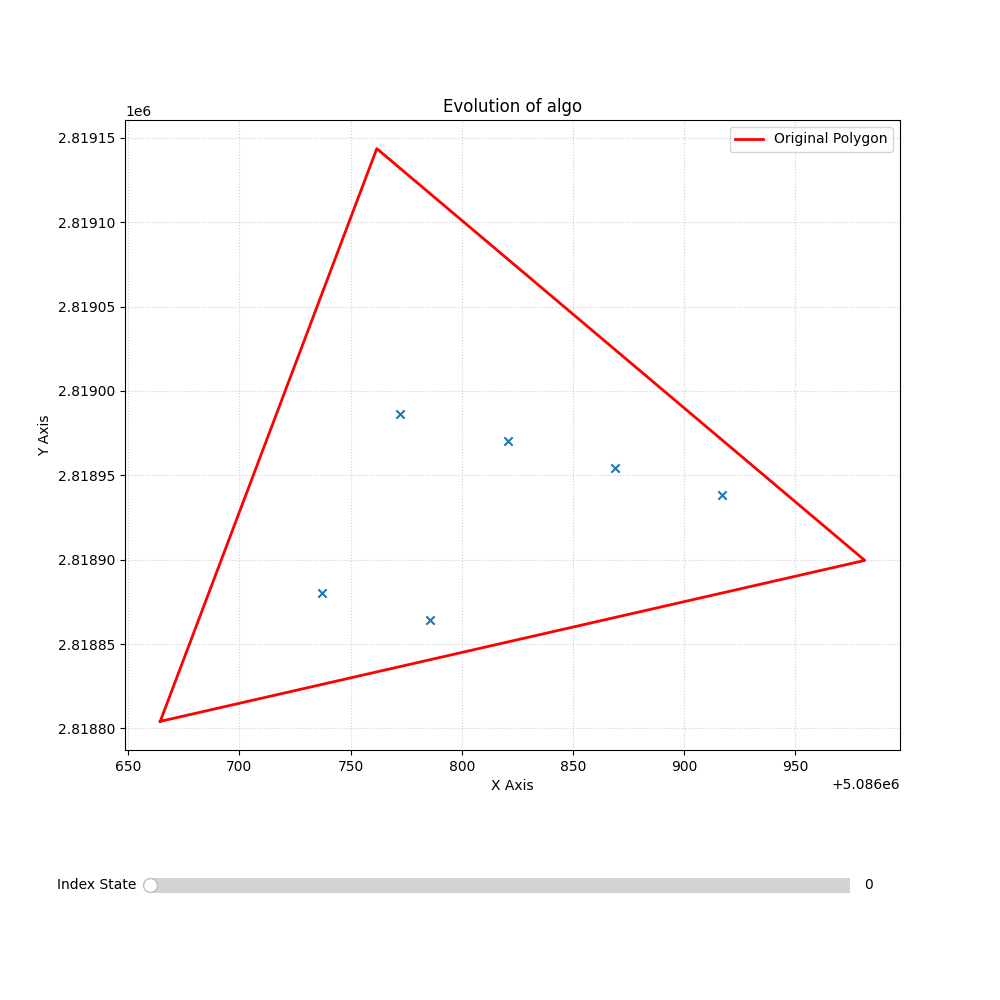

In [47]:
%matplotlib widget
import ast
def show_gp_history(geom, polygon, config, fn):

    filtered_df = gp_results[
        (gp_results["polygon"] == polygon) & (gp_results["config"] == config) & (gp_results["fn"] == fn)
    ]
    xs = ast.literal_eval(filtered_df["x_history"].values[0])
    ys = ast.literal_eval(filtered_df["y_history"].values[0])

    plot_interactive_dataset_gp(
        x_pos=xs, y_pos=ys, polygon=geom
    )

show_gp_history(polygon_2,"polygon 2", "config 1", "fn 1")

In [37]:
gp_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  112 non-null    int64  
 1   polygon     112 non-null    str    
 2   fn          112 non-null    str    
 3   config      112 non-null    str    
 4   fitness     112 non-null    float64
 5   aep_wake    112 non-null    float64
 6   park_cf     112 non-null    float64
 7   park_loss   112 non-null    float64
 8   x_history   112 non-null    str    
 9   y_history   112 non-null    str    
dtypes: float64(4), int64(1), str(5)
memory usage: 8.9 KB


In [35]:
gp_results

,Unnamed: 0,polygon,fn,config,fitness,aep_wake,park_cf,park_loss,x_history,y_history
0,0,polygon 1,fn 1,config 1,8.312210e+03,8.312210e+03,0.063425,0.006948,"[[4767144.72855446, 4767096.51629326, 4767048....","[[2727276.6658523004, 2727292.6209248216, 2727..."
1,1,polygon 1,fn 1,config 2,8.303263e+03,8.303263e+03,0.063357,0.008017,"[[4767144.72855446, 4767096.51629326, 4767048....","[[2727276.6658523004, 2727292.6209248216, 2727..."
2,2,polygon 1,fn 1,config 3,8.281111e+03,8.281111e+03,0.063188,0.010663,"[[4767144.72855446, 4767096.51629326, 4767048....","[[2727276.6658523004, 2727292.6209248216, 2727..."
3,3,polygon 1,fn 1,config 4,8.281111e+03,8.281111e+03,0.063188,0.010663,"[[4767144.72855446, 4767096.51629326, 4767048....","[[2727276.6658523004, 2727292.6209248216, 2727..."
4,4,polygon 1,fn 2,config 1,4.685541e-02,1.166721e+05,0.046855,0.266384,"[[4767144.72855446, 4767096.51629326, 4767048....","[[2727276.6658523004, 2727292.6209248216, 2727..."
...,...,...,...,...,...,...,...,...,...,...
107,107,polygon 4,fn 6,config 4,4.746739e+06,4.746737e+06,0.543291,0.017125,"[[5083827.014638206, 5083993.714474912, 508384...","[[2853422.822187164, 2853603.2665647776, 28536..."
108,108,polygon 4,fn 7,config 1,4.757922e+06,4.757921e+06,0.544571,0.014010,"[[5083827.014638206, 5083993.714474912, 508384...","[[2853422.822187164, 2853603.2665647776, 28536..."
109,109,polygon 4,fn 7,config 2,4.743622e+06,4.743621e+06,0.542935,0.016654,"[[5083827.014638206, 5083993.714474912, 508384...","[[2853422.822187164, 2853603.2665647776, 28536..."
110,110,polygon 4,fn 7,config 3,4.735574e+06,4.735573e+06,0.542014,0.020137,"[[5083827.014638206, 5083993.714474912, 508384...","[[2853422.822187164, 2853603.2665647776, 28536..."


config 1
config 2
config 3
config 4


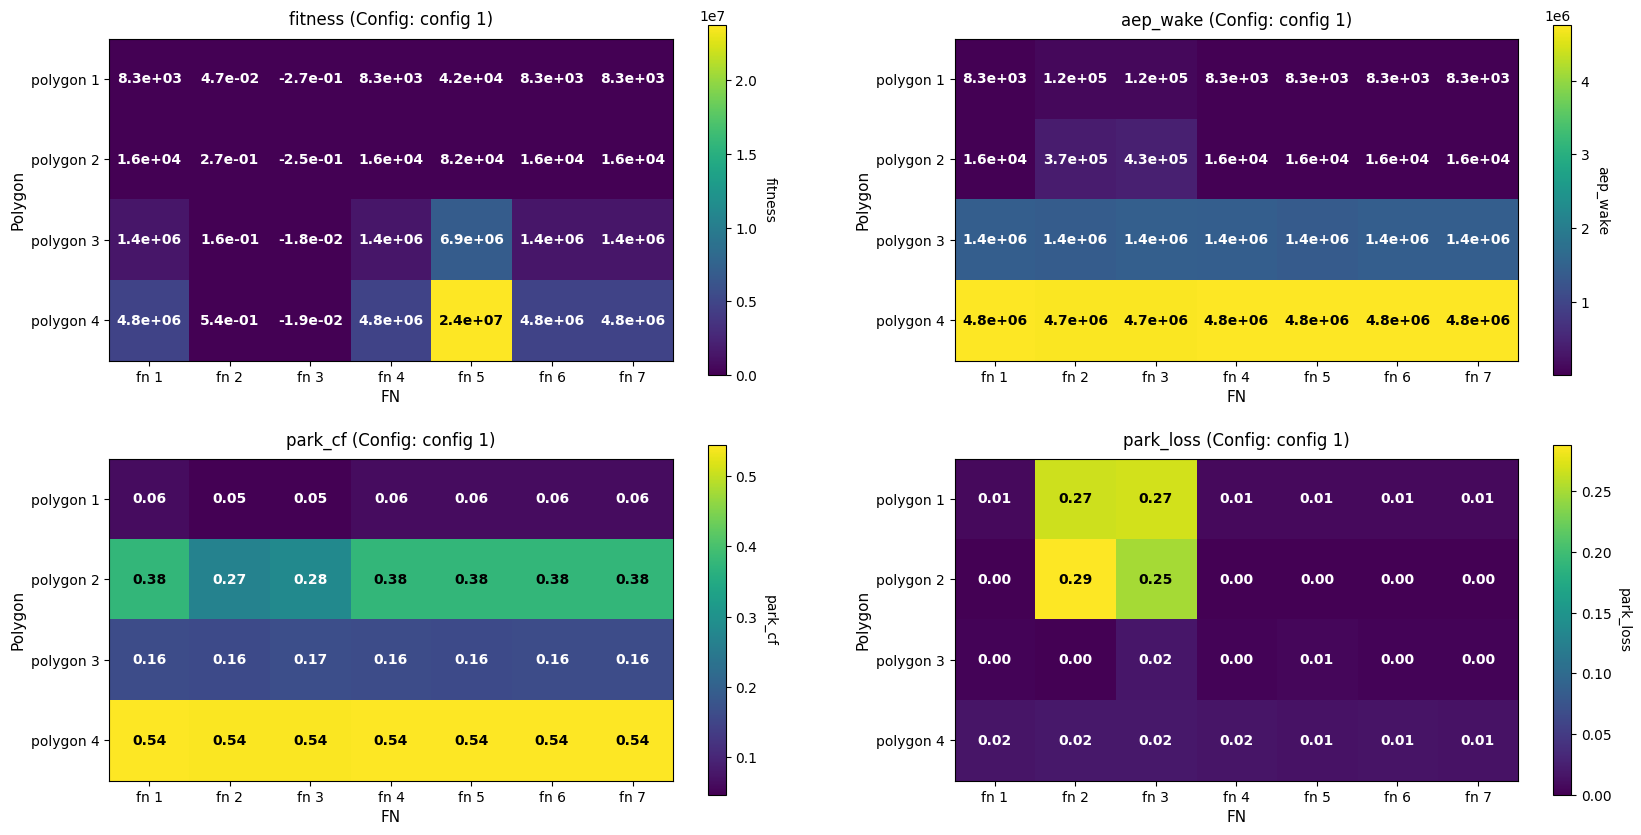

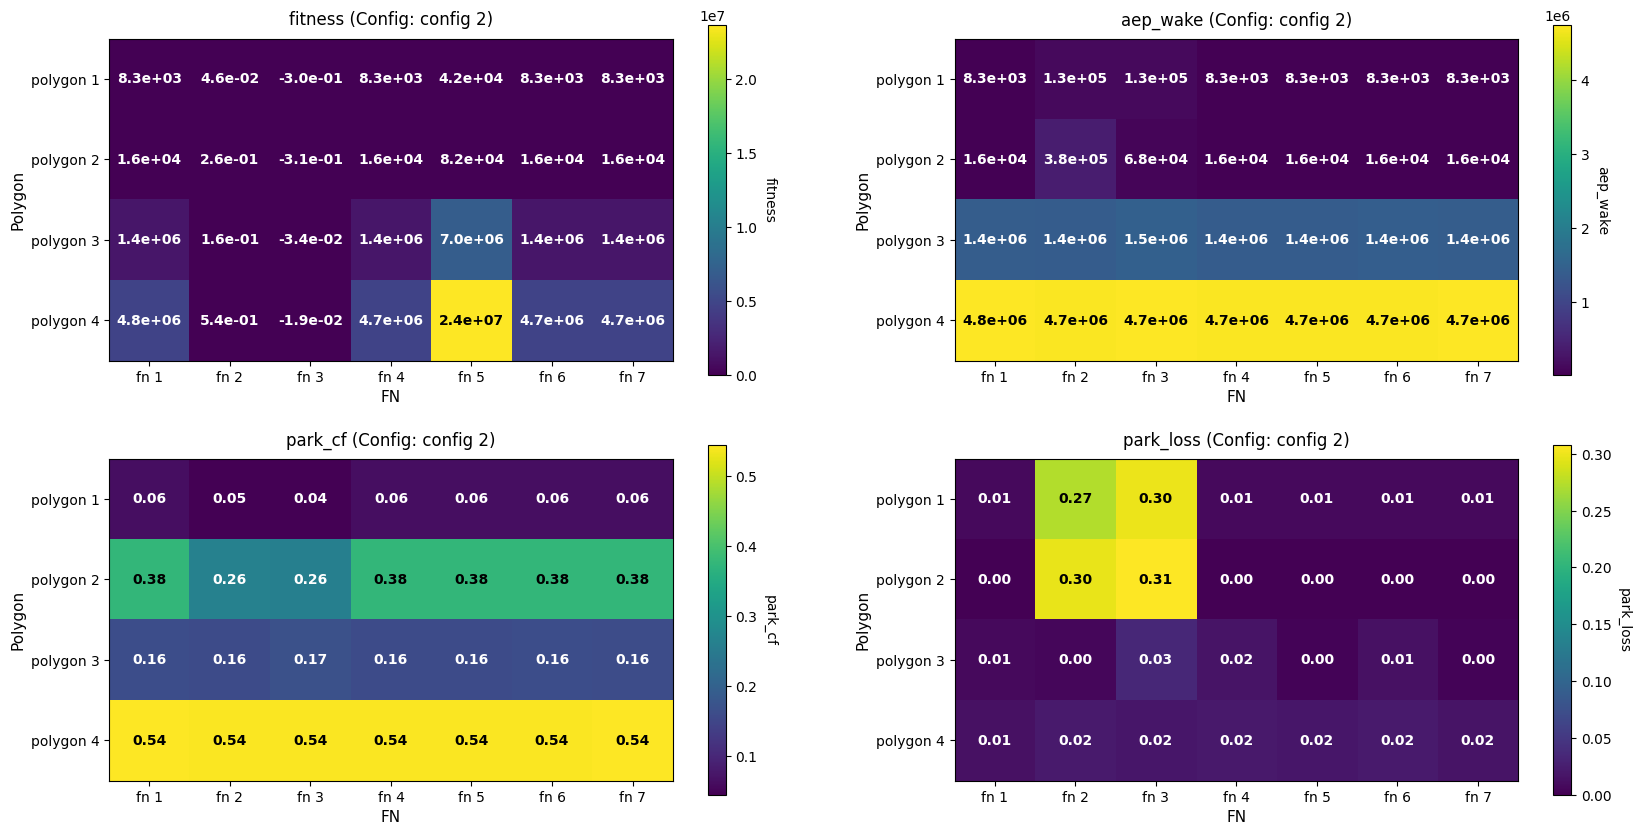

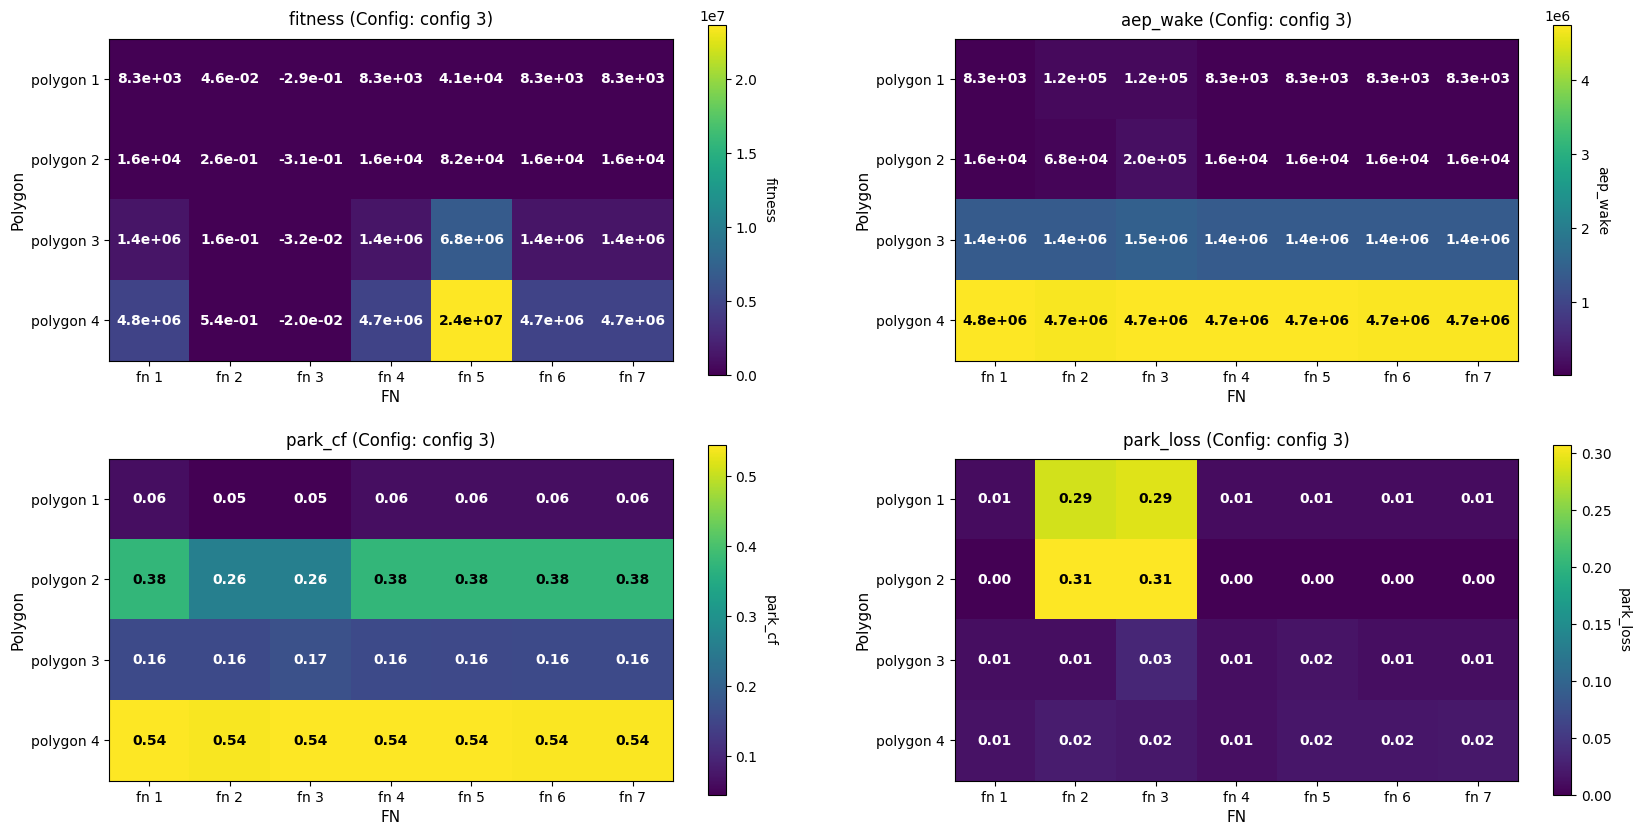

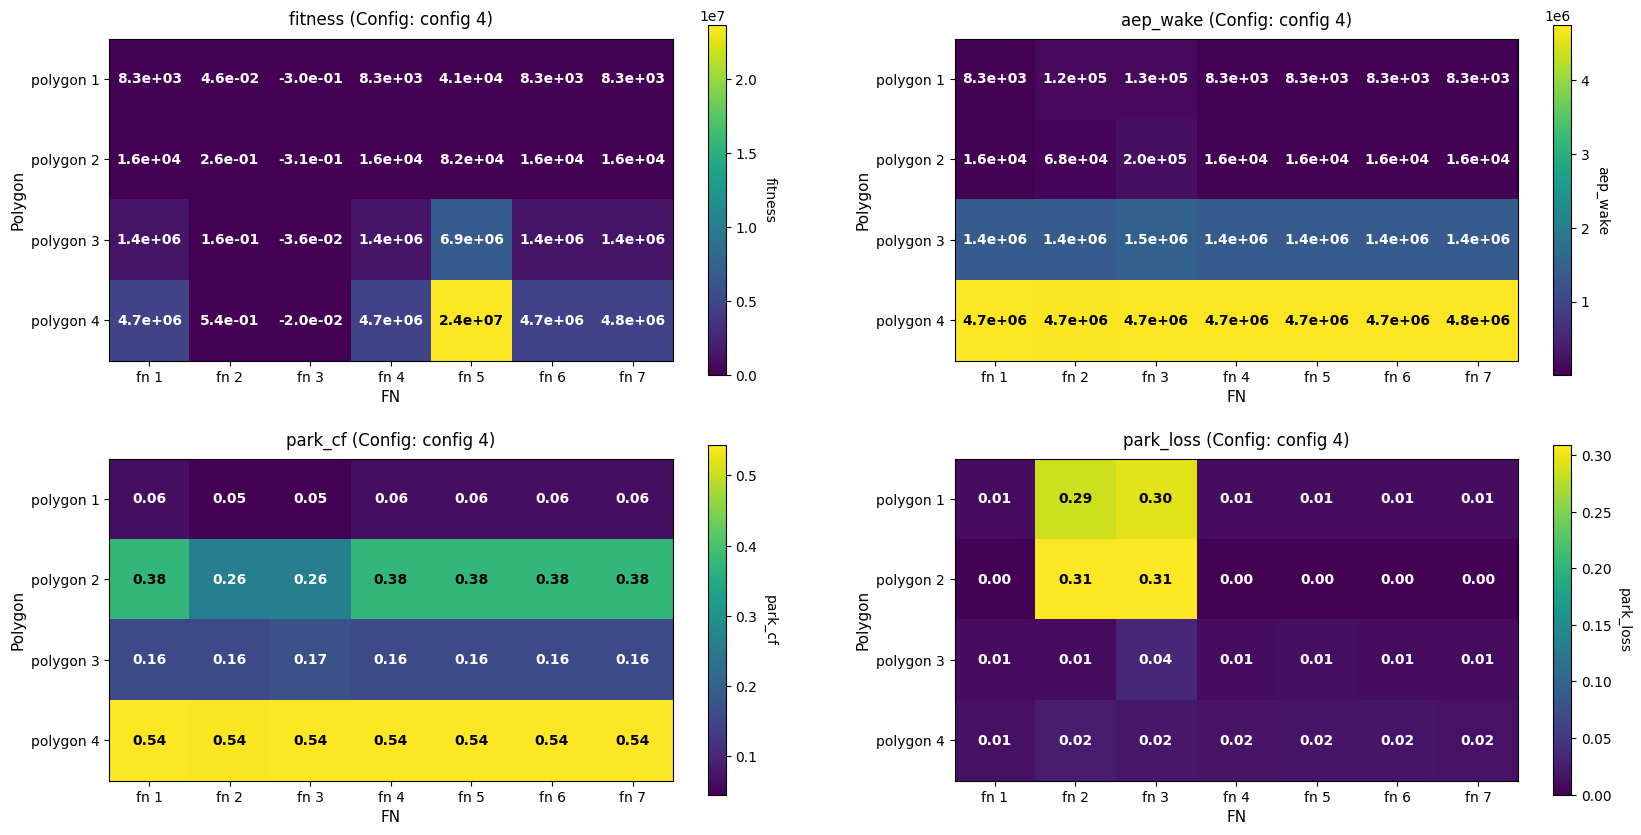

In [36]:
plot_all_results(gp_results)

# Grid Search

In [37]:
gs_results

,Unnamed: 0,polygon,fn,fitness,config,aep_wake,park_cf,park_loss,history
0,0,polygon 1,fn 1,WakeOptimizationResult(fitness=np.float64(3753...,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,NaN
1,1,polygon 1,fn 2,WakeOptimizationResult(fitness=np.float64(0.03...,"(np.float64(20.0), np.float64(7.0), np.float64...",124657.481169,0.037547,0.412130,NaN
2,2,polygon 1,fn 3,WakeOptimizationResult(fitness=np.float64(-0.4...,"(np.float64(20.0), np.float64(7.0), np.float64...",124657.481169,0.037547,0.412130,NaN
3,3,polygon 1,fn 4,WakeOptimizationResult(fitness=np.float64(3753...,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,NaN
4,4,polygon 1,fn 5,WakeOptimizationResult(fitness=np.float64(1876...,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,NaN
5,5,polygon 1,fn 6,WakeOptimizationResult(fitness=np.float64(3753...,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,NaN
6,6,polygon 1,fn 7,WakeOptimizationResult(fitness=np.float64(3753...,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,NaN
7,7,polygon 2,fn 1,WakeOptimizationResult(fitness=np.float64(1146...,"(np.float64(90.0), np.float64(13.0), np.float6...",114642.016746,0.328036,0.127249,NaN
8,8,polygon 2,fn 2,WakeOptimizationResult(fitness=np.float64(0.17...,"(np.float64(85.0), np.float64(11.0), np.float6...",218137.057425,0.172187,0.541892,NaN
9,9,polygon 2,fn 3,WakeOptimizationResult(fitness=np.float64(-0.5...,"(np.float64(85.0), np.float64(11.0), np.float6...",218137.057425,0.172187,0.541892,NaN


In [51]:
gs_results

,Unnamed: 0,polygon,fn,fitness,config,aep_wake,park_cf,park_loss,x_result,y_result
0,0,polygon 1,fn 1,37532.866848,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,"[4766878.284004282, 4766918.8865931425, 476695...","[2727267.7311754865, 2727286.664473613, 272730..."
1,1,polygon 1,fn 2,0.037547,"(np.float64(20.0), np.float64(7.0), np.float64...",124657.481169,0.037547,0.412130,"[4766837.712885989, 4766925.203781686, 4766943...","[2727265.429989098, 2727249.5989066944, 272725..."
2,2,polygon 1,fn 3,-0.412130,"(np.float64(20.0), np.float64(7.0), np.float64...",124657.481169,0.037547,0.412130,"[4766837.712885989, 4766925.203781686, 4766943...","[2727265.429989098, 2727249.5989066944, 272725..."
3,3,polygon 1,fn 4,37532.820930,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,"[4766878.284004282, 4766918.8865931425, 476695...","[2727267.7311754865, 2727286.664473613, 272730..."
4,4,polygon 1,fn 5,187664.288323,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,"[4766878.284004282, 4766918.8865931425, 476695...","[2727267.7311754865, 2727286.664473613, 272730..."
5,5,polygon 1,fn 6,37533.050042,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,"[4766878.284004282, 4766918.8865931425, 476695...","[2727267.7311754865, 2727286.664473613, 272730..."
6,6,polygon 1,fn 7,37532.408144,"(np.float64(25.0), np.float64(14.0), np.float6...",37532.866848,0.057278,0.103197,"[4766878.284004282, 4766918.8865931425, 476695...","[2727267.7311754865, 2727286.664473613, 272730..."
7,7,polygon 2,fn 1,114642.016746,"(np.float64(90.0), np.float64(13.0), np.float6...",114642.016746,0.328036,0.127249,"[5086737.4573104335, 5086820.657310434, 508673...","[2818880.852169344, 2818925.652169344, 2818925..."
8,8,polygon 2,fn 2,0.172187,"(np.float64(85.0), np.float64(11.0), np.float6...",218137.057425,0.172187,0.541892,"[5086812.29035913, 5086884.095856137, 5086813....","[2818874.817478327, 2818887.8086522412, 281889..."
9,9,polygon 2,fn 3,-0.541892,"(np.float64(85.0), np.float64(11.0), np.float6...",218137.057425,0.172187,0.541892,"[5086812.29035913, 5086884.095856137, 5086813....","[2818874.817478327, 2818887.8086522412, 281889..."


/tmp/ipykernel_49393/2924909243.py:40: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  index_slider = Slider(


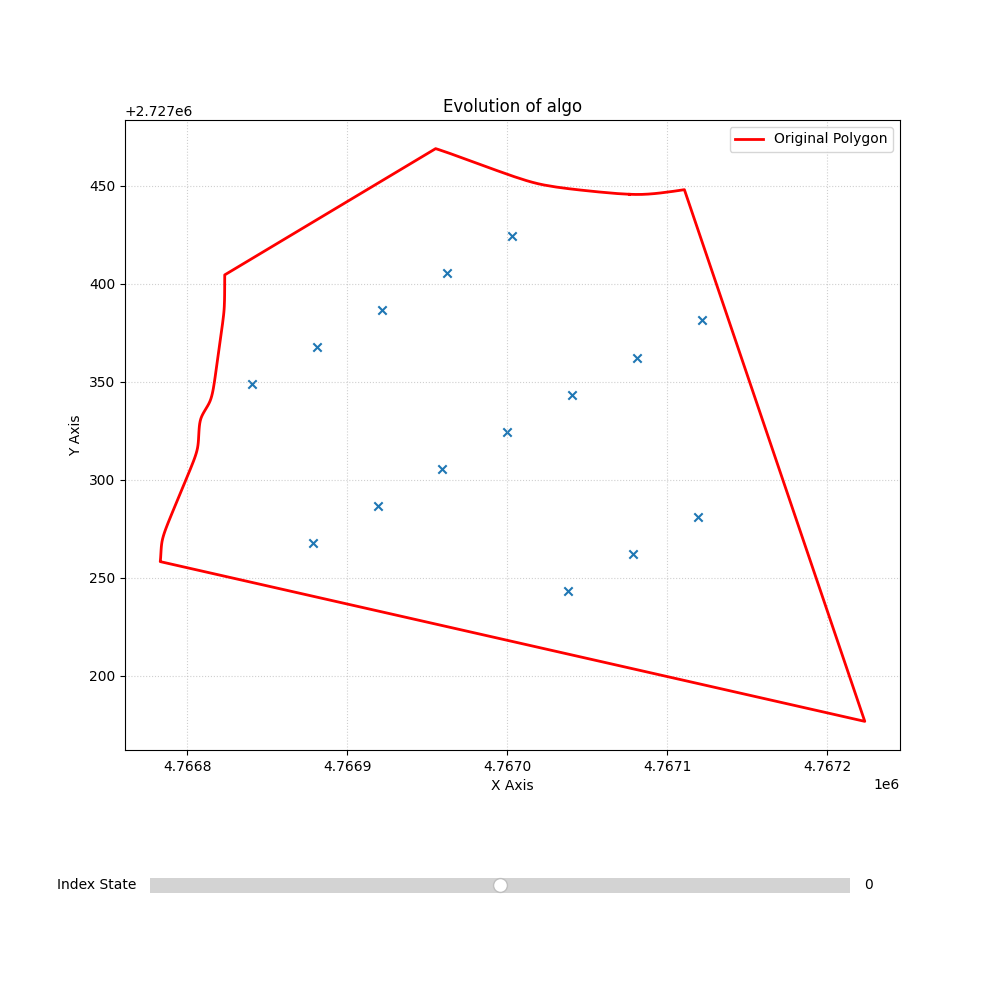

In [65]:
%matplotlib widget
import ast
def show_gs(geom, polygon, fn):

    filtered_df = gs_results[
        (gs_results["polygon"] == polygon) & (gs_results["fn"] == fn)
    ]

    xs = [ast.literal_eval(filtered_df["x_result"].values[0])]
    ys = [ast.literal_eval(filtered_df["y_result"].values[0])]

    plot_interactive_dataset_gp(
        x_pos=xs, y_pos=ys, polygon=geom
    )

show_gs(polygon_1,"polygon 1", "fn 1")

(np.float64(25.0), np.float64(14.0), np.float64(7.0))
(np.float64(20.0), np.float64(7.0), np.float64(3.0))
(np.float64(90.0), np.float64(13.0), np.float64(7.0))
(np.float64(85.0), np.float64(11.0), np.float64(3.0))


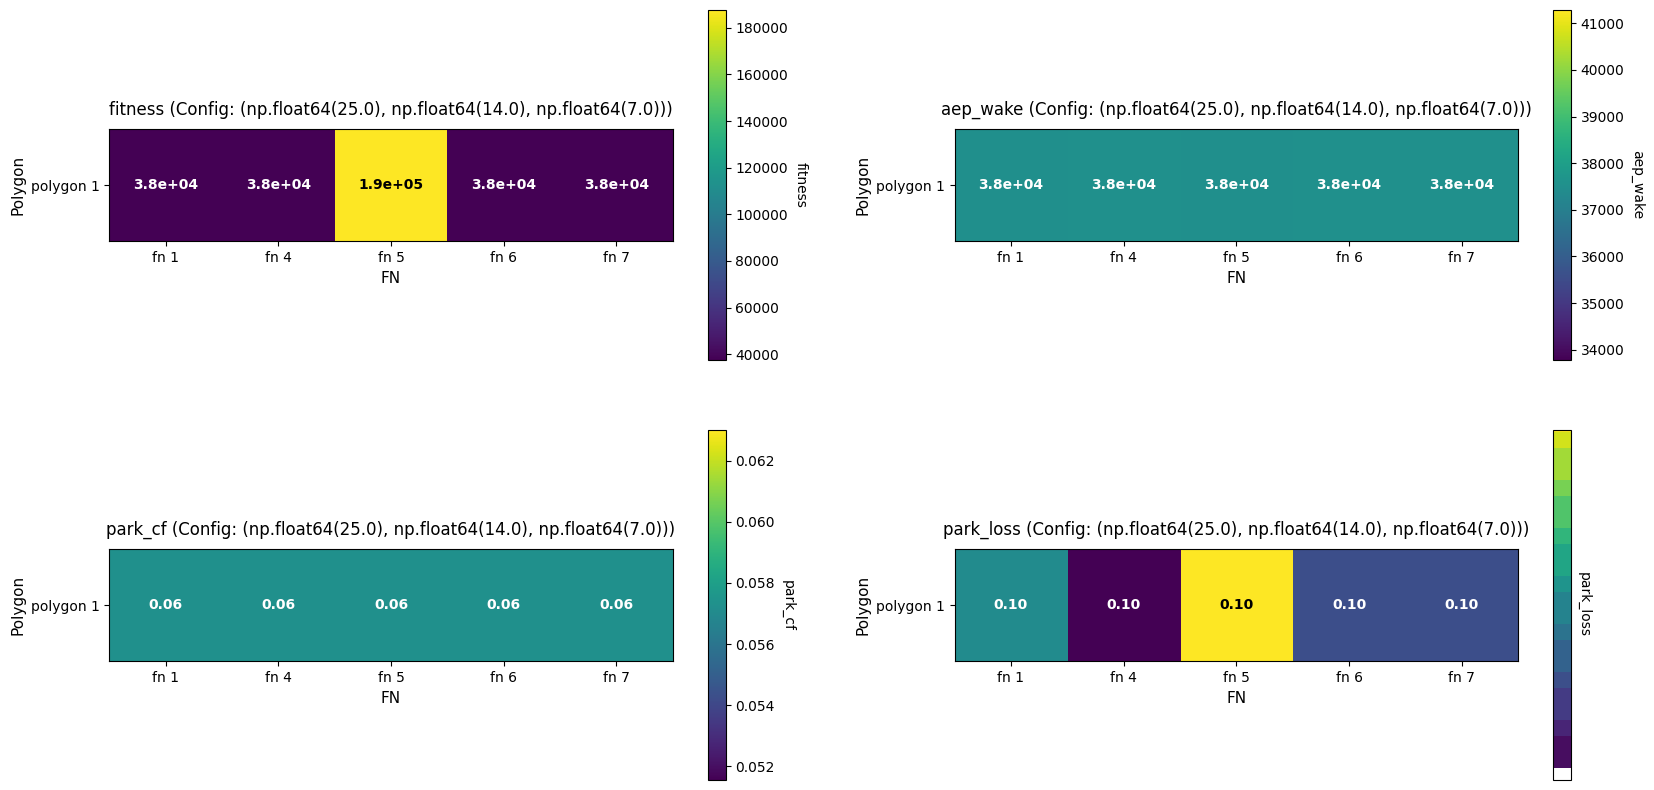

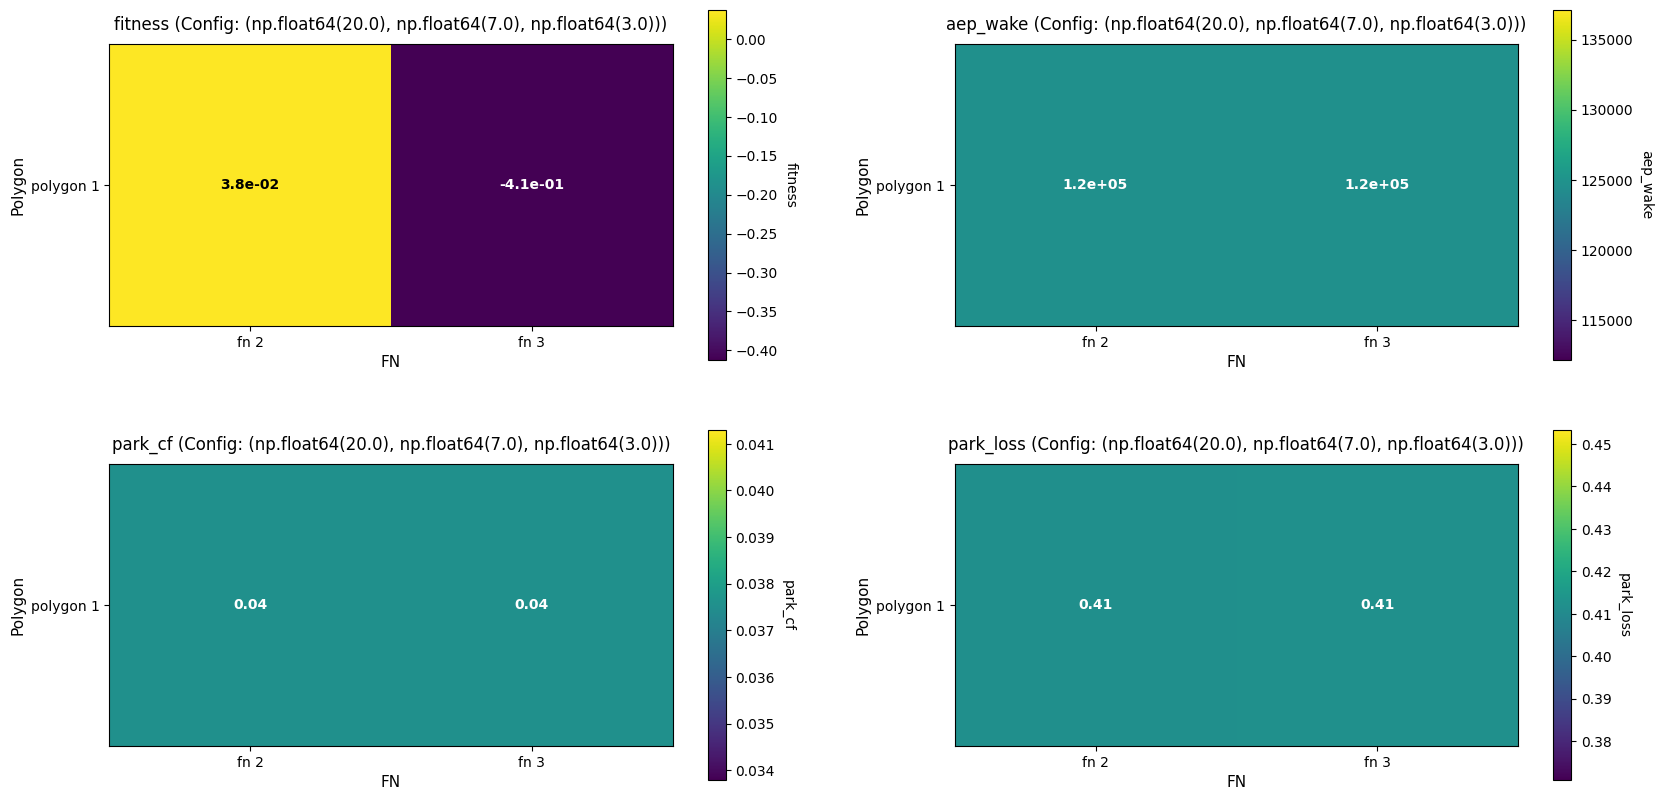

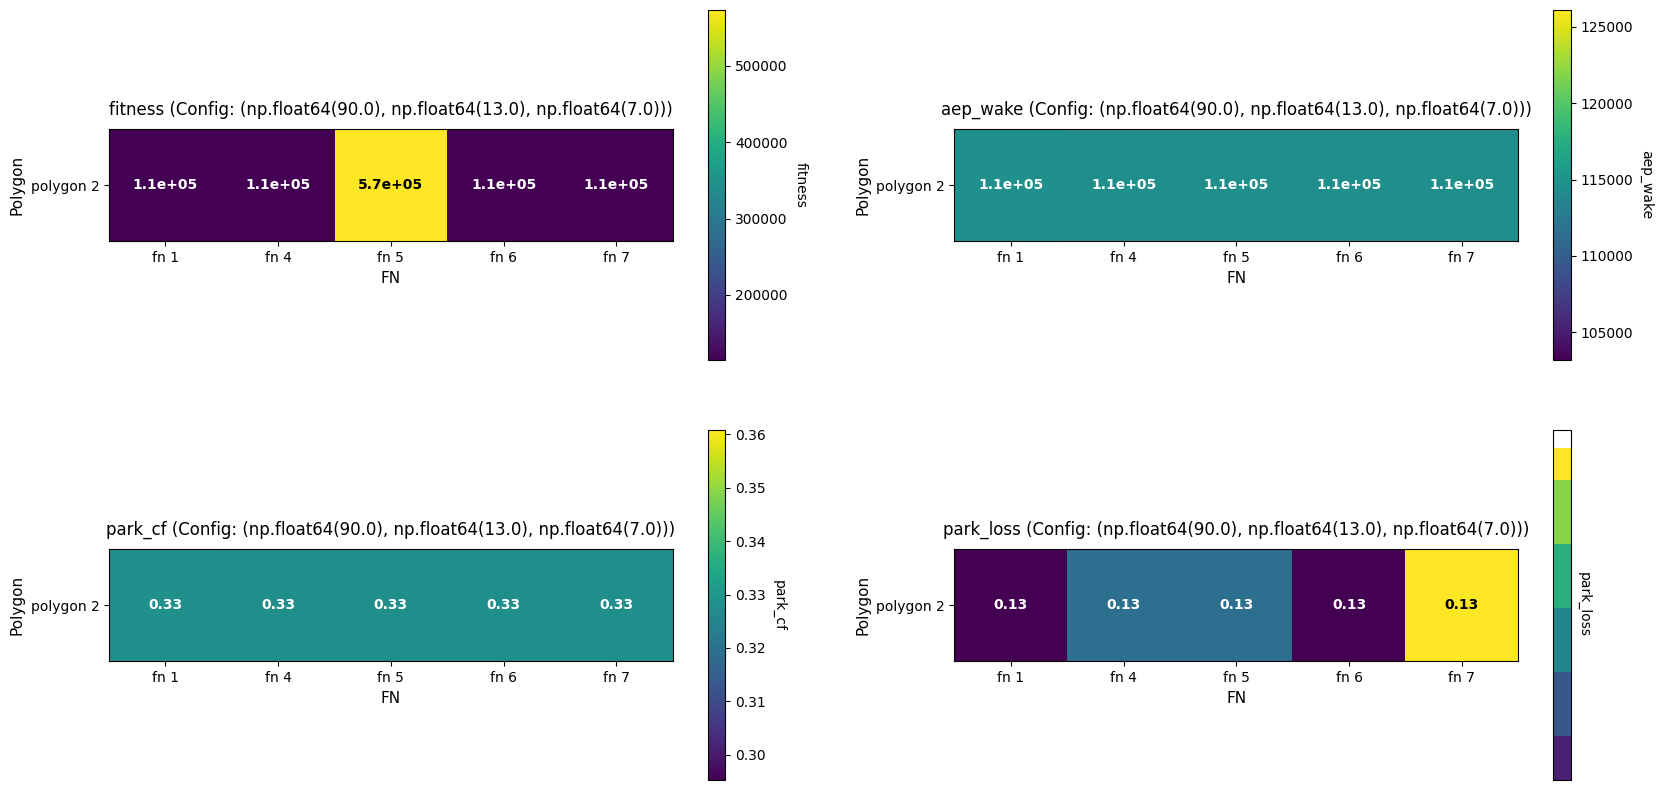

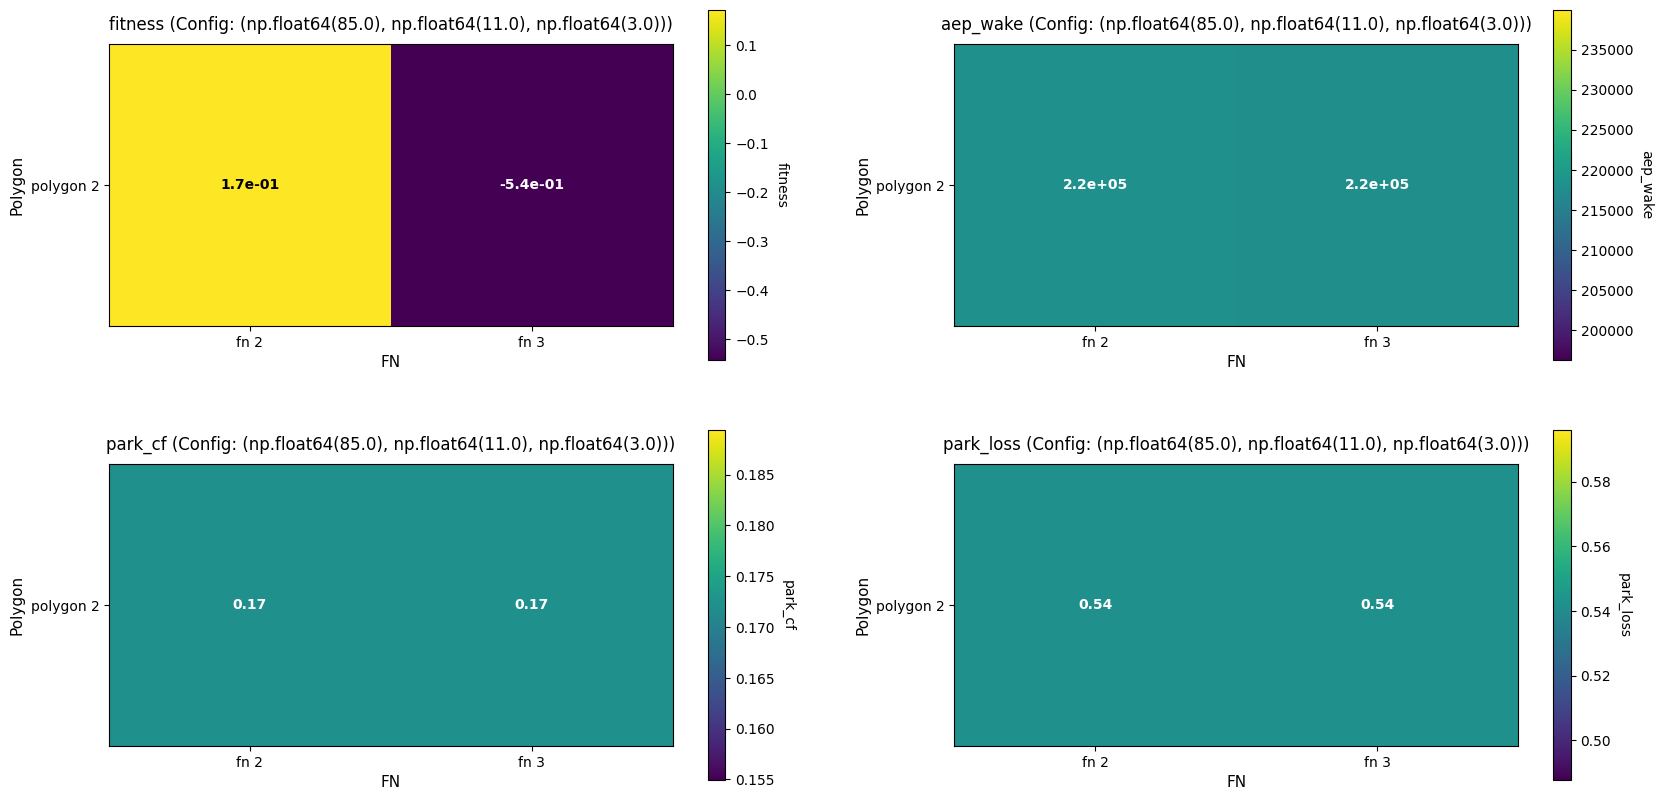

In [43]:
plot_all_results(gs_results)

In [ ]:
#1. mostrar para algoritmo gentico
#2. mostrar para gp optimize
#3. mostrar para grid search

#figurar como mostrar datos generales para uno y luego se replica en los demas.
#Lo de mostrar como evolucionan es algo aparte realmente.

#5. investigar sobre la direccion general

#6. Ir armando la presentacion_ ir comparando para ver tambien si toca volver a ejecutar scripts.

# 5. Exp

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

def plot_pca_orientation(poly: Polygon, ax):
    # Extract exterior coordinates and force 2D (x, y), dropping Z/M if present
    coords = np.array(poly.exterior.coords)[:-1][:, :2]  
    centroid = np.array([poly.centroid.x, poly.centroid.y])
    
    # Center points (75, 2) - (2,) works now!
    centered = coords - centroid
    cov = np.cov(centered, rowvar=False)
    
    # Eigen decomposition
    evals, evecs = np.linalg.eigh(cov)
    major_vec = evecs[:, np.argmax(evals)]  # Principal axis vector
    
    # Calculate angle in degrees
    angle_rad = np.arctan2(major_vec[1], major_vec[0])
    angle_deg = np.degrees(angle_rad)
    
    # Plotting
    x, y = coords[:, 0], coords[:, 1]
    ax.plot(np.append(x, x[0]), np.append(y, y[0]), color='blue', lw=2, label='Polygon')
    ax.scatter(*centroid, color='red', zorder=5, label='Centroid')
    
    # Draw axis line
    length = max(poly.bounds[2] - poly.bounds[0], poly.bounds[3] - poly.bounds[1]) * 0.6
    p1 = centroid - major_vec * length
    p2 = centroid + major_vec * length
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', linestyle='--', lw=2, label=f'PCA Axis ({angle_deg:.1f}°)')
    
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title("Method 1: Principal Component Analysis")
    return angle_deg

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon


def plot_obb_orientation(poly: Polygon, ax):
    # Get minimum area rotated rectangle
    mrr = poly.minimum_rotated_rectangle
    mrr_coords = np.array(mrr.exterior.coords)[:-1]

    # Find edge vectors and lengths
    edges = np.diff(np.vstack([mrr_coords, mrr_coords[0]]), axis=0)
    lengths = np.hypot(edges[:, 0], edges[:, 1])

    # Identify the longer edge
    longest_idx = np.argmax(
        lengths[:2]
    )  # Rectangles have pairs of equal sides
    long_edge = edges[longest_idx]

    # Angle of the long edge
    angle_rad = np.arctan2(long_edge[1], long_edge[0])
    angle_deg = np.degrees(angle_rad) % 180
    if angle_deg > 90:
        angle_deg -= 180

    x, y = poly.exterior.xy
    ax.plot(x, y, color="blue", lw=2, label="Polygon")

    bx, by = mrr.exterior.xy
    ax.plot(bx, by, color="gray", linestyle=":", label="Oriented Bounding Box")

    centroid = [poly.centroid.x, poly.centroid.y]
    unit_vec = long_edge / np.linalg.norm(long_edge)
    length = max(lengths) * 0.6

    p1 = centroid - unit_vec * length
    p2 = centroid + unit_vec * length
    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        color="green",
        linestyle="--",
        lw=2,
        label=f"OBB Axis ({angle_deg:.1f}°)",
    )

    ax.set_aspect("equal")
    ax.legend()
    ax.set_title("Method 2: Oriented Bounding Box")
    return angle_deg

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

def plot_area_moment_orientation(poly: Polygon, ax):
    coords = np.array(poly.exterior.coords)[:-1]
    x = coords[:, 0]
    y = coords[:, 1]
    
    # Shift coordinates to centroid for numerical stability
    cx, cy = poly.centroid.x, poly.centroid.y
    x_c = x - cx
    y_c = y - cy
    
    # Cross terms for Green's Theorem
    x_next = np.roll(x_c, -1)
    y_next = np.roll(y_c, -1)
    cross = x_c * y_next - x_next * y_c
    
    # Central moments of area
    I_xx = np.sum((y_c**2 + y_c * y_next + y_next**2) * cross) / 12.0
    I_yy = np.sum((x_c**2 + x_c * x_next + x_next**2) * cross) / 12.0
    I_xy = np.sum((x_c * y_next + 2 * x_c * y_c + 2 * x_next * y_next + x_next * y_c) * cross) / 24.0
    
    # Major orientation angle
    angle_rad = 0.5 * np.arctan2(-2 * I_xy, I_yy - I_xx)
    angle_deg = np.degrees(angle_rad)
    
    # Direction vector
    dir_vec = np.array([np.cos(angle_rad), np.sin(angle_rad)])
    

    px, py = poly.exterior.xy
    ax.plot(px, py, color='blue', lw=2, label='Polygon')
    ax.scatter(cx, cy, color='red', zorder=5, label='Centroid')
    
    length = max(poly.bounds[2] - poly.bounds[0], poly.bounds[3] - poly.bounds[1]) * 0.6
    p1 = np.array([cx, cy]) - dir_vec * length
    p2 = np.array([cx, cy]) + dir_vec * length
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='purple', linestyle='--', lw=2, label=f'Inertia Axis ({angle_deg:.1f}°)')
    
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title("Method 3: Second Moment of Area")
    return angle_deg

np.float64(23.32529925879656)

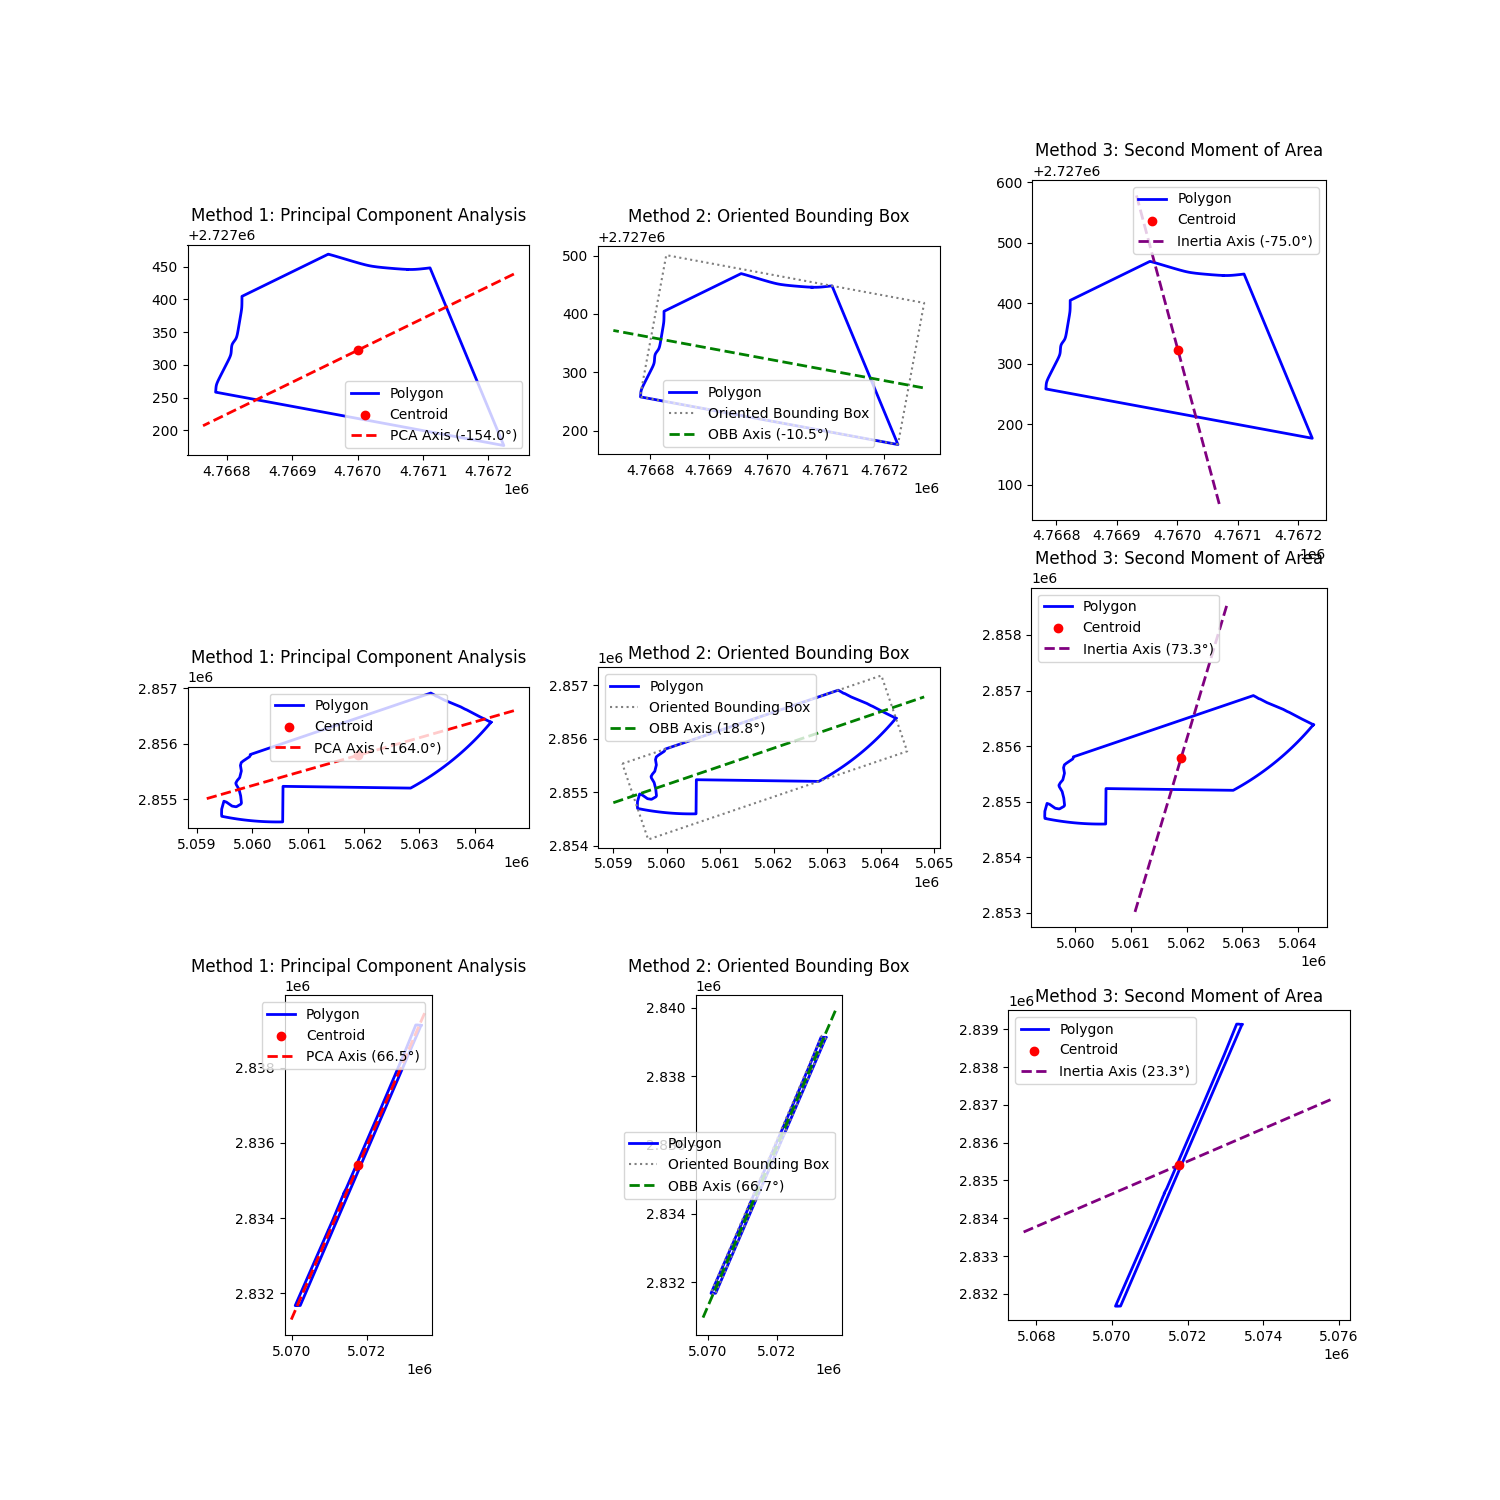

In [98]:
from shapely.plotting import plot_polygon

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
polygon_a = gdf.geometry.iloc[33601] # e_10m_33602
polygon_b = gdf.geometry.iloc[36641] # e_10m_36642
polygon_c = gdf.geometry.iloc[36622] # e_10m_36623

plot_pca_orientation(polygon_a, ax=axes[0,0])
plot_obb_orientation(polygon_a, ax=axes[0,1])
plot_area_moment_orientation(polygon_a, ax=axes[0,2])

plot_pca_orientation(polygon_b, ax=axes[1,0])
plot_obb_orientation(polygon_b, ax=axes[1,1])
plot_area_moment_orientation(polygon_b, ax=axes[1,2])

plot_pca_orientation(polygon_c, ax=axes[2,0])
plot_obb_orientation(polygon_c, ax=axes[2,1])
plot_area_moment_orientation(polygon_c, ax=axes[2,2])